# PED 5: análisis básico de datos climáticos con ERA5

En esta práctica se trabajará con datos del reanálisis ERA5 descargados por el/la propio/a estudiante desde el portal Copernicus Climate Data Store (CDS).

La tarea es doble:

1. representar una serie temporal diaria de precipitación para un punto próximo a Madrid;
2. elaborar un mapa de precipitación sobre la Comunidad de Madrid a partir de datos en rejilla.

La práctica permite familiarizarse con un flujo de trabajo muy habitual en análisis climático:

- localización y descarga de datos;
- carga del archivo en un entorno de análisis;
- inspección de variables y dimensiones;
- transformación básica de unidades y escalas temporales;
- representación gráfica e interpretación.

## Recordatorio importante

En ERA5, la precipitación total (`total precipitation`, `tp`) se expresa en **metros de agua**. Para expresarla en milímetros, se multiplica por 1000. 

In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

## 2. Serie temporal de precipitación en un punto

En este primer apartado trabajaremos con el archivo CSV descargado para un punto próximo a Madrid.

El objetivo es obtener una **serie diaria de precipitación** a partir de datos horarios.

### Tarea
Escriba en la variable `csv_file` el nombre exacto de su archivo descargado.

In [6]:
csv_file = "reanalysis-era5-single-levels-timeseries-sfcx8_t7_4y.csv"

df = pd.read_csv(csv_file)
df.head()

,valid_time,tp,latitude,longitude
0,2019-06-01 00:00:00,0.0,40.0,-4.0
1,2019-06-01 01:00:00,0.0,40.0,-4.0
2,2019-06-01 02:00:00,0.0,40.0,-4.0
3,2019-06-01 03:00:00,0.0,40.0,-4.0
4,2019-06-01 04:00:00,0.0,40.0,-4.0


### Pregunta 1
Observe la tabla cargada y responda brevemente:

- ¿qué columnas aparecen?
- ¿qué columna contiene la fecha y hora?
- ¿qué columna contiene la precipitación?

In [7]:
df.columns

Index(['valid_time', 'tp', 'latitude', 'longitude'], dtype='object')

## 3. Conversión de la fecha y hora

Convierta la columna temporal al tipo fecha-hora de `pandas`.

Después, cree una nueva columna que contenga solo la fecha, sin la hora.

In [8]:
# Sustituya el nombre de la columna temporal si fuera necesario
df["valid_time"] = pd.to_datetime(df["valid_time"])

# Cree una columna solo con la fecha
df["date"] = df["valid_time"].dt.date

df.head()

,valid_time,tp,latitude,longitude,date
0,2019-06-01 00:00:00,0.0,40.0,-4.0,2019-06-01
1,2019-06-01 01:00:00,0.0,40.0,-4.0,2019-06-01
2,2019-06-01 02:00:00,0.0,40.0,-4.0,2019-06-01
3,2019-06-01 03:00:00,0.0,40.0,-4.0,2019-06-01
4,2019-06-01 04:00:00,0.0,40.0,-4.0,2019-06-01


## 4. Unidades de precipitación

En ERA5, la variable `total precipitation` (`tp`) se expresa en metros de agua. Para pasar a milímetros, se multiplica por 1000. 

### Tarea
Cree una nueva columna con la precipitación en milímetros.

In [9]:
# Sustituya 'tp' por el nombre real de la columna si fuera distinto
df["tp_mm"] = df["tp"] * 1000

df[["valid_time", "tp", "tp_mm"]].head()

,valid_time,tp,tp_mm
0,2019-06-01 00:00:00,0.0,0.0
1,2019-06-01 01:00:00,0.0,0.0
2,2019-06-01 02:00:00,0.0,0.0
3,2019-06-01 03:00:00,0.0,0.0
4,2019-06-01 04:00:00,0.0,0.0


## 5. De datos horarios a precipitación diaria

A diferencia de la temperatura media, la precipitación diaria no se obtiene promediando los valores horarios, sino **sumándolos**.

### Tarea
Agrupe los datos por día y calcule la precipitación total diaria.

In [10]:
daily_precip = (
    df.groupby("date", as_index=False)["tp_mm"]
      .sum()
      .rename(columns={"tp_mm": "precip_mm_day"})
)

daily_precip.head()

,date,precip_mm_day
0,2019-06-01,0.000000
1,2019-06-02,0.000000
2,2019-06-03,0.000000
3,2019-06-04,0.000477
4,2019-06-05,0.384808


## 6. Representación de la serie temporal

Represente la serie diaria obtenida.

### Pregunta 2
Describa brevemente el comportamiento de la precipitación en el periodo analizado.
No se trata solo de decir si llueve más o menos, sino de indicar si la precipitación aparece de forma continua o concentrada en unos pocos episodios.

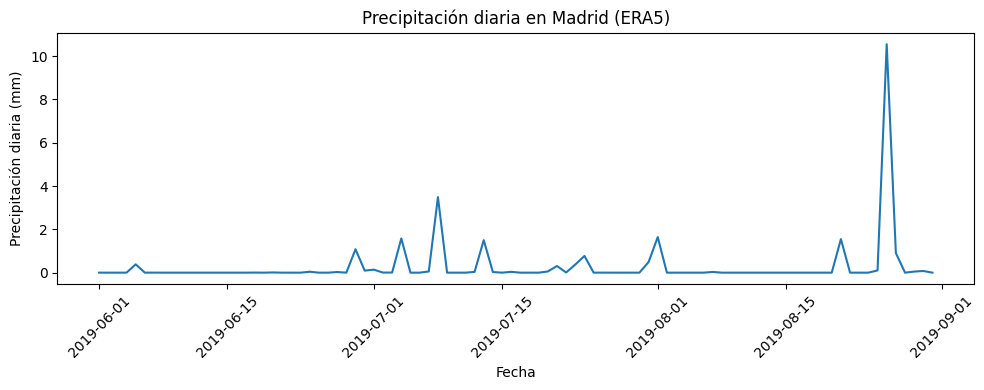

In [11]:
plt.figure(figsize=(10,4))
plt.plot(daily_precip["date"], daily_precip["precip_mm_day"])
plt.xlabel("Fecha")
plt.ylabel("Precipitación diaria (mm)")
plt.title("Precipitación diaria en Madrid (ERA5)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Mapa de precipitación sobre la Comunidad de Madrid

En este segundo apartado trabajaremos con un archivo NetCDF descargado desde ERA5 en rejilla.

El objetivo es generar un mapa de precipitación para la región de Madrid.

In [31]:
#nc_file = "AQUI_ESCRIBA_EL_NOMBRE_DE_SU_ARCHIVO.nc"
nc_file ="data_stream-oper_stepType-accum_2.nc"
ds = xr.open_dataset(nc_file)
ds

<xarray.Dataset> Size: 1MB
Dimensions:     (valid_time: 2208, latitude: 9, longitude: 13)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 18kB 2019-06-01 ... 2019-08-31T23...
  * latitude    (latitude) float64 72B 41.0 40.75 40.5 40.25 ... 39.5 39.25 39.0
  * longitude   (longitude) float64 104B -5.0 -4.75 -4.5 ... -2.5 -2.25 -2.0
    expver      (valid_time) <U4 35kB ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 1MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-25T08:43 GRIB to CDM+CF via cfgrib-0.9.1...

### Pregunta 3
A partir de la salida del dataset, indique:

- nombre de la variable principal de precipitación;
- dimensiones disponibles;
- coordenadas espaciales incluidas.

In [32]:
list(ds.data_vars)

['tp']

## 8. Selección de la variable y del instante temporal

Seleccione la variable de precipitación y un instante temporal concreto.

Si su archivo contiene todas las horas de un día, puede:
- representar una hora concreta, o
- sumar todas las horas del día para obtener precipitación diaria acumulada.

In [33]:
tp = ds["tp"] * 1000  # conversión de m a mm

tp

<xarray.DataArray 'tp' (valid_time: 2208, latitude: 9, longitude: 13)> Size: 1MB
array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
...
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.00286102, 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]]], shape=(2208, 9, 13), dtype=float32)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 18kB 2019-06-01 ... 2019-08-31T23...
  * latitude    (latitude) float64 72B 41.0 40.75 40.5 40.25 ... 39.5 39.25 39.0
  * longitude   (longitude) float64 104B -5.0 -4.75 -4.5 ... -2.5 -2.25 -2.0
    expver      (valid_time) <U4 35kB ...

## 9. Construcción de un mapa diario

Si el archivo contiene varias horas del mismo día, obtenga la precipitación diaria sumando a lo largo de la dimensión temporal.

In [34]:
# Esta celda asume que el archivo contiene varias horas del mismo día
tp_day = tp.sum(dim="valid_time")

tp_day

<xarray.DataArray 'tp' (latitude: 9, longitude: 13)> Size: 468B
array([[51.327705, 41.088104, 38.122654, 45.344353, 60.962677, 55.350304,
        38.36775 , 38.384438, 36.79228 , 46.925068, 59.892178, 63.551426,
        75.94203 ],
       [65.31619 , 51.938534, 33.864975, 41.100502, 46.25082 , 34.859657,
        17.799854, 26.8116  , 37.347317, 47.522068, 42.05227 , 46.59176 ,
        59.016705],
       [65.656654, 48.962593, 30.790806, 22.550106, 23.002625, 13.118744,
        21.931171, 36.43942 , 47.10102 , 39.489746, 28.835773, 32.382965,
        58.506966],
       [31.303406, 20.606041, 19.982338, 12.738228, 16.420841, 26.552677,
        36.375046, 36.471844, 37.620544, 29.972553, 23.202896, 26.202202,
        51.91183 ],
       [ 7.741928, 12.554646, 15.768528, 20.168781, 25.43068 , 32.952785,
        31.301022, 22.166729, 29.689789, 33.568382, 32.797337, 34.504414,
        45.63427 ],
       [31.069279, 32.488823, 33.99372 , 38.39588 , 40.749073, 37.742615,
        27.692318, 18.020153, 21.960735, 31.438828, 36.688805, 38.131714,
        47.786713],
       [15.691757, 17.025948, 21.25597 , 24.052143, 29.932499, 30.252457,
        23.059845, 17.996311, 21.354675, 27.685642, 27.096272, 34.122467,
        45.193195],
       [ 8.536816, 13.221741, 17.561913, 16.646862, 15.6703  , 15.182018,
        14.808178, 18.500328, 23.645878, 29.814243, 25.906086, 35.740376,
        44.98148 ],
       [10.109425, 14.508247, 16.357899, 12.681961, 12.866497, 15.240192,
        17.141819, 28.911114, 35.58922 , 38.990974, 43.81609 , 50.50564 ,
        58.580875]], dtype=float32)
Coordinates:
    number     int64 8B ...
  * latitude   (latitude) float64 72B 41.0 40.75 40.5 40.25 ... 39.5 39.25 39.0
  * longitude  (longitude) float64 104B -5.0 -4.75 -4.5 ... -2.5 -2.25 -2.0

## 10. Representación del mapa

Genere un mapa sencillo del campo de precipitación.

### Pregunta 4
Describa brevemente el patrón espacial observado:
- ¿es homogéneo o heterogéneo?
- ¿aparecen zonas con más precipitación que otras?
- ¿qué limitaciones tiene esta representación?

In [35]:
#tp_madrid = tp_day.sel(
#    latitude=slice(41.0, 39.5),
#    longitude=slice(-5.0, -2.5)
#)

#tp_madrid

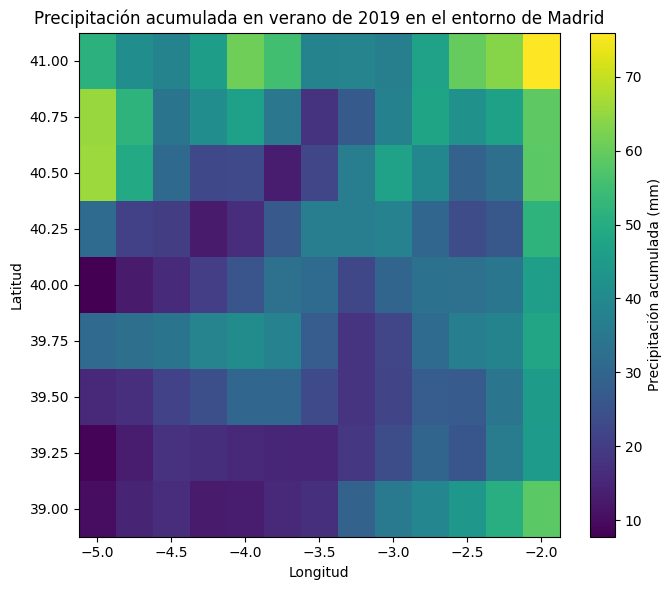

In [36]:
tp_madrid = tp_day
plt.figure(figsize=(7,6))
tp_madrid.plot(cbar_kwargs={"label": "Precipitación acumulada (mm)"})
plt.title("Precipitación acumulada en verano de 2019 en el entorno de Madrid")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.tight_layout()
plt.show()

In [39]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Load Madrid boundary
madrid = gpd.read_file("madrid.geojson")

# Plot
fig, ax = plt.subplots(figsize=(8, 7))

tp_madrid.plot(
    ax=ax,
    cmap="viridis",
    cbar_kwargs={"label": "Precipitación acumulada (mm)"}
)

madrid.boundary.plot(ax=ax, edgecolor="red", linewidth=1.5)

ax.set_title("Precipitación acumulada en verano de 2019")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")

plt.show()

ModuleNotFoundError: No module named 'geopandas'